### Building a basic chatbot with langgraph(GRAPH API)


components of langgraph
- edges
- nodes
- states

//Let's say we want to create Blog from YT video
---[ transcript]---[title generator]---[content generator]--(nodes+edges)(LLM +Prompt for title and content generation) {states can be accessed by any nodes and contains info in lets say variables}{its not memory}[state graph]


In [30]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


// add_mesages to append message (reducers) in single variable

In [31]:
class State(TypedDict):
    #Messages have the type list. The 'add_messages' function
    #in the annotation defines how this state key should be updated 
    #(in this case, it appends messages to the list , rathr than overwriting them)
    messages: Annotated[list, add_messages] #reducer
    


In [32]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [33]:
from langchain_groq import ChatGroq

In [34]:
from langchain.chat_models import init_chat_model

In [35]:
llm=ChatGroq(model="qwen/qwen3-32b")

In [36]:
## node functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [37]:
graph_builder=StateGraph(State)
graph_builder.add_node("chatbot", chatbot)

graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

graph=graph_builder.compile()

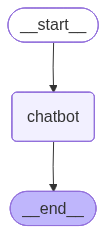

In [38]:
graph

In [39]:
graph.invoke({"messages":[{"role":"user","content":"What is the capital of France?"}]})

{'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='edc4b825-76ed-4b88-9f3f-ce2f3e226df9'),
  AIMessage(content="<think>\nOkay, the user is asking for the capital of France. Let me think. I remember that France is a country in Europe, and their capital is a well-known city. I think it's Paris. Wait, is that right? Let me double-check. Yes, Paris is definitely the capital. I don't think there's any confusion with other cities like Lyon or Marseille. Maybe sometimes people might think it's Versailles because of the palace, but the capital is definitely Paris. I should just confirm once more. Quick search in my memory: yes, Paris is the capital and largest city of France. The government is based there, so that's correct. Alright, I can confidently say the answer is Paris.\n</think>\n\nThe capital of France is Paris. Paris is not only the political and administrative center of the country but also a major global city known fo

In [40]:
for event in graph.stream({"messages":[{"role":"user","content":"What is the capital of France?"}]}):
    print(event)

{'chatbot': {'messages': [AIMessage(content='<think>\nOkay, so the user is asking, "What is the capital of France?" Let me think about how to approach this. First, I need to recall basic geography. France is a country in Western Europe, and I remember that its capital is a well-known city. The most likely answer is Paris, but I want to make sure there\'s no confusion with other cities like Lyon or Marseille, which are major cities in France but not capitals.\n\nWait, I should double-check if there\'s any chance of a different answer. Sometimes countries have different capitals for administrative or historical reasons. For example, some countries have a capital that\'s not the largest city. However, in the case of France, Paris is both the political and administrative capital. Also, Paris is famous for landmarks like the Eiffel Tower and the Louvre, which are associated with the capital of France. \n\nI should also consider if there\'s any possibility of a different capital due to polit

### Chatbot with tools

tool call from tool calling LLM

In [41]:
from langchain_tavily import TavilySearch
tool=TavilySearch(max_results=3)
tool.invoke("Who is the best ODI cricket player . Name one")



{'query': 'Who is the best ODI cricket player . Name one',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.instagram.com/reel/DXnfuDlCbNC',
   'title': 'Greatest ODI Batsman Of All Time - Instagram',
   'content': "Sachin Tendulkar. Number one on the list. Virat Kohli number two. I'll give you a hint: he's a wicketkeeper. Giving another hint: he is",
   'score': 0.69820654,
   'raw_content': None},
  {'url': 'https://www.icc-cricket.com/rankings/batting/mens/odi',
   'title': "Men's ODI Batting Rankings – Top One Day Batsmen in the World",
   'content': "[![Image 1: Header Logo](https://images.icc-cricket.com/image/private/t_q-best/v1698133655/prd/assets/logos/icc-white-logo.svg)](https://www.icc-cricket.com/rankings/batting/mens/odi#nolink). [Rankings](https://www.icc-cricket.com/rankings). [Ticketing](https://www.icc-cricket.com/rankings/batting/mens/odi#). [![Image 2: Header Logo](https://images.icc-cricket.com/image/private/t_q-best/v

In [42]:
#custom function
def multiply(a:int,b:int)->int:
    """Multiplies two numbers and returns the result.
    
    args:
        a (int): The first number to multiply.
        b (int): The second number to multiply.
    
    output:
        int: The product of the two numbers.
    """
    return a*b

In [43]:
tools=[tool,multiply]

In [44]:
llm_with_tool=llm.bind_tools(tools)

In [45]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'versions': {'langchain-core': '1.4.6', 'langchain': '1.3.7'}}, output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000017DBE033410>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000017DBDF62210>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for compreh

In [ ]:
## stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## node definition
def tool_calling_llm(state: State):
    return {
        "messages": [
            llm_with_tool.invoke(state["messages"])
        ]
    }
##Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

##adding edges
builder.add_edge(START,"tool_calling_llm")
#builder.add_edge("tool_calling_llm","tools",condition=tools_condition(tools))
#builder.add_edge("tool_calling_llm",END,condition=lambda state: not tools_condition(tools)(state))
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge(
    "tools",
    "tool_calling_llm"
)

graph=builder.compile()




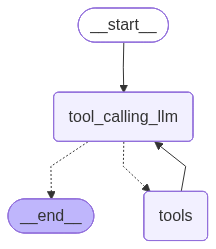

In [70]:
graph

In [71]:
response=graph.invoke({"messages":[{"role":"user","content":"What is the recent AI news?"}]})

In [72]:
response

{'messages': [HumanMessage(content='What is the recent AI news?', additional_kwargs={}, response_metadata={}, id='98bfed38-5cf3-4554-b145-8ea72dcc8698'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for recent AI news. Let me see which tool to use. The available tools are tavily_search and multiply. Multiply is for math, so definitely not that. Tavily_search is the way to go.\n\nNow, looking at the parameters for tavily_search. The user wants recent news, so I should set the time_range. The options are day, week, month, year. Since they said "recent," maybe "week" is appropriate. But sometimes "recent" could be broader. Alternatively, check if there\'s a start_date or end_date. The time_range parameter is specifically for this, so setting time_range to "week" would limit results to the last 7 days. That makes sense.\n\nAlso, the topic parameter: the user is asking about AI news. The topic options are general, news, finance. The description s

In [73]:
response["messages"][-1].content

'Here’s a summary of recent AI developments based on the latest reports:\n\n### 1. **AI Industry Trends & Financials**  \n- **Cost Escalation**: Companies are spending billions on AI tools, with some firms (e.g., an unnamed company) spending up to **$500 million/month** on AI licenses. Startups like Anthropic (Claude) and OpenAI (ChatGPT) are competing fiercely, with Anthropic recently filing for an IPO and OpenAI expected to follow.  \n- **Data Center Challenges**: Growing AI demand is straining data center capacity, risking a "compute crunch" that could drive up costs for developers and users.  \n- **AI Agents**: Tools like **Claude Code** are popularizing autonomous AI agents that automate tasks like coding, shifting how developers work.\n\n### 2. **AI’s Impact on Jobs**  \n- **Entry-Level Job Concerns**: Recent graduates report AI replacing entry-level roles, though experts caution against blaming AI for all job losses. The debate highlights broader economic shifts and automation c

In [74]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (5e3w2nav9)
 Call ID: 5e3w2nav9
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: week
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.theguardian.com/technology/2026/jun/07/billions-spent-hypothetical-returns-the-ai-boom-explained-with-six-charts", "title": "Billions spent and hypothetical returns: the AI boom explained with six charts | AI (artificial intelligence) | The Guardian", "content": "“The costs are getting completely out of control,” says Liam Betsworth, founder of the British AI startup Pendra. Software developers in his circle are using agen

In [75]:
response_=graph.invoke({"messages":[{"role":"user","content":"What is the recent AI news and what is 5 multiplied by 6?"}]})

In [79]:
for m in response_["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news and what is 5 multiplied by 6?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (c3b22cpwa)
 Call ID: c3b22cpwa
  Args:
    query: recent AI news
    time_range: week
    topic: news
  multiply (gqhc67dk1)
 Call ID: gqhc67dk1
  Args:
    a: 5
    b: 6
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.axios.com/2026/06/08/ai-news-nvidia-cosmos-3-openai-sites-solara-rtx-spark", "title": "Axios C-Suite: 3 new AI developments for the week of June 6 - Axios", "score": 0.7783298, "published_date": "Mon, 08 Jun 2026 09:57:05 GMT", "content": "# Axios C-Suite: 3 new AI developments for the week of June 6. Fast action AI software:** OpenAI launched Sites, a Co

React agent architecture 1) Act 2) observe 3) reason

In [78]:
for event in graph.stream(
    {
        "messages":[
            {
                "role":"user",
                "content":"What is the recent AI news and what is 5 multiplied by 6?"
            }
        ]
    }
):
    print(event)

{'tool_calling_llm': {'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, let\'s tackle this user query. They want two things: recent AI news and the result of 5 multiplied by 6. \n\nFirst, for the recent AI news, I need to use the tavily_search function. The user mentioned "recent," so I should set the time_range parameter to "day" to get the latest updates. The topic is AI, so the query will be "recent AI news." I\'ll make sure to use the default search_depth unless the user specifies otherwise. Since they didn\'t mention any specific domains to include or exclude, I\'ll leave those parameters as default.\n\nNext, the multiplication part. The user is asking for 5 multiplied by 6. That\'s straightforward. The multiply function requires two integers, a and b. So, I\'ll set a=5 and b=6. No need for any additional parameters here.\n\nWait, let me double-check the tavily_search parameters. The time_range options are day, week, month, year. Since they want "re